In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Vector を三次元に描画する

In [35]:
from draw3d import *

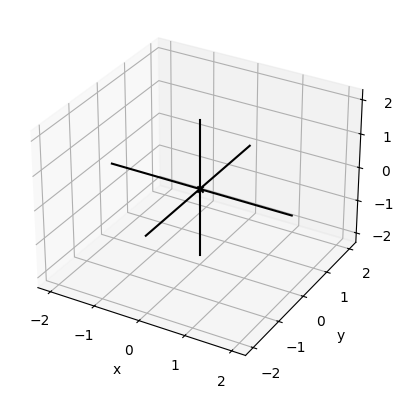

In [36]:
draw3d()

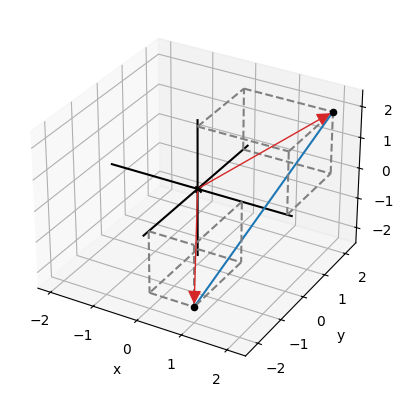

In [37]:
draw3d(
    Points3D((2,2,2), (1,-2,-2)),
    Arrow3D((2,2,2)),
    Arrow3D((1,-2,-2)),
    Segment3D((2,2,2), (1,-2,-2)),
    Box3D(2,2,2),
    Box3D(1,-2,-2)
)

## 3.2 すべての座標が +1 or -1 の 3次元ベクトルをすべて描画

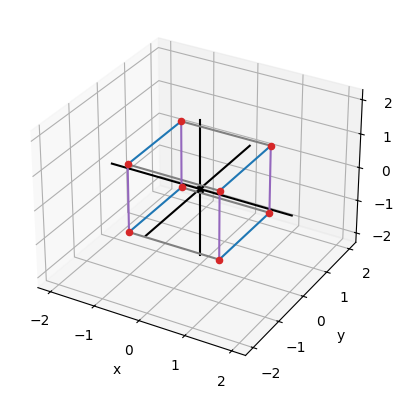

In [38]:
pm1 = [1, -1]
vertices = [(x,y,z) # すべての頂点
            for x in pm1
            for y in pm1
            for z in pm1]

edges = [((-1, y, z), (1, y, z), gray) # すべての辺. x, y, z それぞれで色分けしている
         for y in pm1
         for z in pm1] + \
        [((x, -1, z), (x, 1, z), blue)
           for x in pm1
           for z in pm1] + \
        [((x, y, -1), (x, y, 1), purple)
         for x in pm1
         for y in pm1]


draw3d(
    Points3D(*vertices, color=red),
    *[Segment3D(*edge) for edge in edges]
)

In [39]:
def add (*vectors):
    by_coordinate = zip(*vectors)
    coordinate_sums = [sum(coords) for coords in by_coordinate]
    return tuple(coordinate_sums)

## 3.2.4 長さと距離を計算する

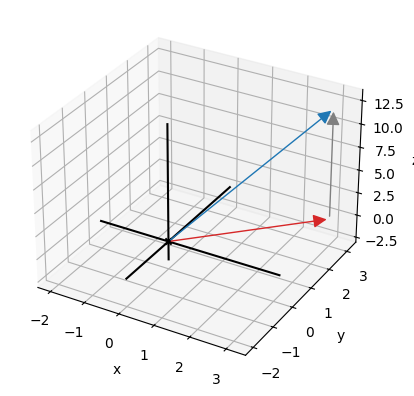

In [40]:
draw3d(
    Arrow3D((3, 3, 0), color=red),
    Arrow3D((3, 3, 12), color=blue),
    Arrow3D((3, 3, 12), (3, 3, 0), color=gray)
)

三次元上の距離を求めるには2次元上を求めそれを底辺として(図では赤線の $z=0$ のベクトルの長さ)、その終点から垂直にz軸方向に伸ばしたベクトル (つまりz軸の値そのもの)を高さとした斜辺を計算すれば良いので、公式は以下のようになる.

$長さ = \sqrt{\sqrt{z^2+y^2}^2 + z^2} = \sqrt{x^2 + y^2 + z^2}$

In [41]:
from math import sqrt
def length (v: (int, int, int)):
    return sqrt(sum([coord ** 2 for coord in v]))

## 3.2.5 角度と方向を計算する

- 3次元ベクトルを真上 (z軸側) から見たときのベクトル (つまり xy 平面上にベクトルが落とす影) を  $\phi$ (ファイ) で表し、
- 真横 (x または y 軸. 3次元ベクトルが作る面に垂直な角度) から見たときのベクトルを  $\theta$ (シータ) で表す.
- ベクトルの長さを $r$ で表す

これら 3 つの数字 $\phi, \theta, r$ を直交座標に対して **球座標** と呼ぶ. 極座標 (平面) では角度の差を簡単にとることができたが、球座標では $\theta$ の角度を取ることはできない (見る座標によって2つのベクトルの成す角度が異なるため). 2つの3次元ベクトルの $\theta$ の成す角は、2つのベクトルの作る面に対して垂直の方向から見たときの角度とする. この角度は **内積** を計算することで求めることができる.